Exercise 1 – Random dataset following a quadratic distribution
Points are generated in 2-D; the class boundary is the parabola x2 = x1(2)
 (label 1 = above the parabola, 0 = below). A linear SVM cannot separate this, but polynomial (degree 2) and RBF kernels can.

Dataset note: this is the one exercise whose text itself asks for a generated dataset ("random dataset following a quadratic distribution"), so the points are generated here on purpose (seed 0, 500 points) – there is no real dataset that has a known parabolic boundary. Exercise 2 below uses real data.

(500, 3) | class balance: {1: 293, 0: 207}


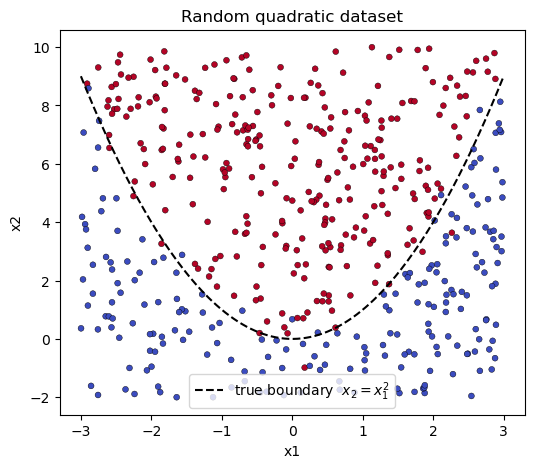

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

rng = np.random.default_rng(0)
n = 500
x1 = rng.uniform(-3, 3, n)
x2 = rng.uniform(-2, 10, n)
label = (x2 > x1**2 + rng.normal(0, 0.5, n)).astype(int)     # quadratic boundary + a little noise

quad = pd.DataFrame({"x1": x1, "x2": x2, "class": label})
print(quad.shape, "| class balance:", quad["class"].value_counts().to_dict())

plt.figure(figsize=(6, 5))
plt.scatter(x1, x2, c=label, cmap="coolwarm", s=18, edgecolor="k", linewidth=0.3)
xs = np.linspace(-3, 3, 200); 
plt.plot(xs, xs**2, "k--", label="true boundary  $x_2=x_1^2$")
plt.xlabel("x1"); 
plt.ylabel("x2"); 
plt.title("Random quadratic dataset"); 
plt.legend(); 
plt.show()

In [3]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

X = quad[["x1", "x2"]].values; y = quad["class"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=5, stratify=y)

models = {
    "Linear":             SVC(kernel="linear", C=1),
    "Polynomial (deg 2)": SVC(kernel="poly", degree=2, C=10, coef0=1, gamma="scale"),
    "RBF":                SVC(kernel="rbf", C=10, gamma="scale"),
}
rows = []
for name, m in models.items():
    m.fit(X_train, y_train)
    rows.append({"Kernel": name, "Train acc": m.score(X_train, y_train),
                 "Test acc": m.score(X_test, y_test), "Support vectors": m.n_support_.sum()})
pd.DataFrame(rows).round(3)

,Kernel,Train acc,Test acc,Support vectors
0,Linear,0.803,0.847,163
1,Polynomial (deg 2),0.969,0.980,77
2,RBF,0.966,0.973,76


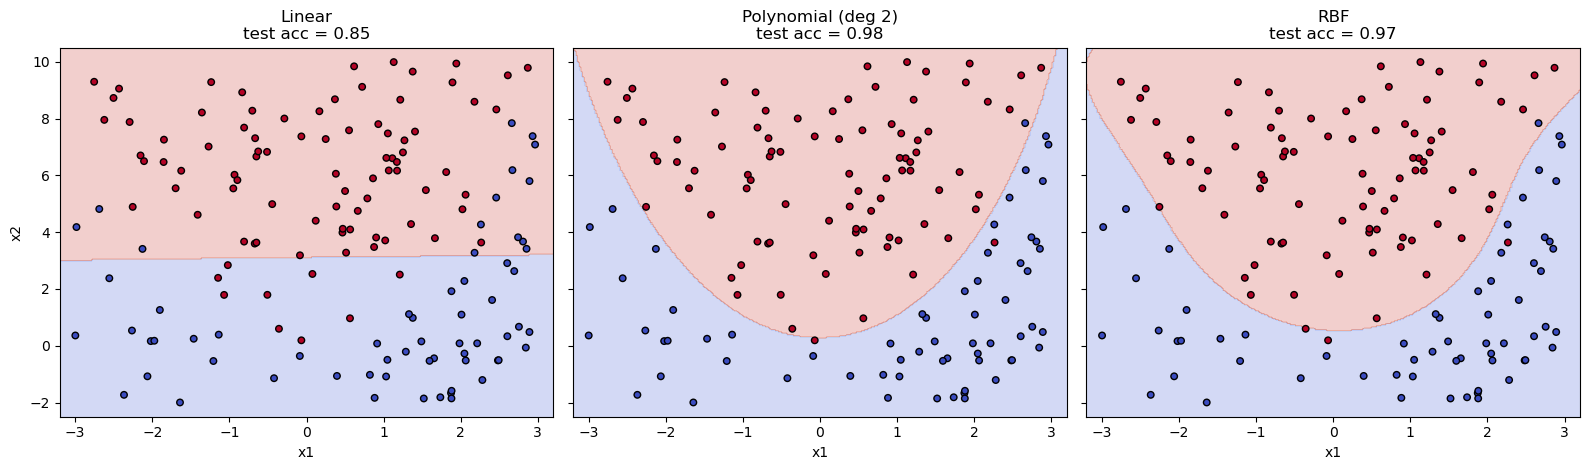

                precision    recall  f1-score   support

Below parabola       0.95      0.98      0.97        62
Above parabola       0.99      0.97      0.98        88

      accuracy                           0.97       150
     macro avg       0.97      0.97      0.97       150
  weighted avg       0.97      0.97      0.97       150



In [4]:
from sklearn import metrics

# Decision regions for the three kernels
xx, yy = np.meshgrid(np.linspace(-3.2, 3.2, 300), np.linspace(-2.5, 10.5, 300))
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)
for ax, (name, m) in zip(axes, models.items()):
    Z = m.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap="coolwarm", edgecolor="k", s=22)
    ax.set_title(f"{name}\ntest acc = {m.score(X_test, y_test):.2f}"); ax.set_xlabel("x1")
axes[0].set_ylabel("x2"); plt.tight_layout(); plt.show()

print(metrics.classification_report(y_test, models["RBF"].predict(X_test), target_names=["Below parabola", "Above parabola"]))

Exercise 2 – Classify messages as spam / not spam (word frequency + message length)
Dataset – SMS Spam Collection (Kaggle: uciml/sms-spam-collection-dataset, UCI SMS Spam Collection). Link: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset Records: 5,572 real SMS messages (5,169 after removing 403 exact duplicates; 653 spam / 4,516 ham) · Target: spam (1 = spam). Features (built from the message text): word-frequency percentages – freq_free ("free"), freq_win ("win/won/winner/prize"), freq_call ("call/txt/mobile/claim") and the ham-typical freq_lol ("lol/ok/sure/later") – plus message_length, num_links, num_digits and capital_ratio. Preprocessing: duplicates dropped (so identical messages cannot appear in both train and test); features standardised inside the pipeline; hyper-parameters chosen with 5-fold grid search. Why it fits: genuine spam / ham messages, and the exercise asks for word-frequency and message-length features.

In [9]:
import os, re, urllib.request
import numpy as np
import pandas as pd

# ---- Dataset loader ----
DATA_DIR = "data"
def load_data(filename, url, **read_csv_kwargs):
    """Read a real dataset. Uses ./data/<filename> if present (e.g. downloaded from Kaggle);
    otherwise downloads the public copy given in `url` and caches it in ./data/."""
    path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(path):
        os.makedirs(DATA_DIR, exist_ok=True)
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=60) as resp, open(path, "wb") as f:
            f.write(resp.read())
    return pd.read_csv(path, **read_csv_kwargs)
sms = load_data("sms.tsv", "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv",
                sep="\t", header=None, names=["label", "text"])
n_raw = len(sms)

sms = sms.drop_duplicates().reset_index(drop=True)
print(f"{n_raw} messages -> {len(sms)} after dropping exact duplicates")

def sms_features(text):
    """Word-frequency percentages + simple length / character features for one message."""
    words = re.findall(r"[a-z']+", text.lower())
    n = max(len(words), 1)
    pct = lambda vocab: round(100 * sum(w in vocab for w in words) / n, 2)
    letters = [c for c in text if c.isalpha()]
    return {
        "freq_free":      pct({"free"}),
        "freq_win":       pct({"win", "won", "winner", "prize"}),
        "freq_call":      pct({"call", "txt", "mobile", "claim"}),
        "freq_lol":       pct({"lol", "ok", "sure", "later"}),          # ham-typical words
        "message_length": len(text),
        "num_links":      len(re.findall(r"www\.|http", text.lower())),
        "num_digits":     sum(c.isdigit() for c in text),
        "capital_ratio":  round(sum(c.isupper() for c in letters) / max(len(letters), 1), 3),
    }

mail = pd.DataFrame([sms_features(t) for t in sms["text"]])
mail["spam"] = (sms["label"] == "spam").astype(int)
print(mail.shape, "| nulls:", mail.isnull().sum().sum(), "| spam share:", mail.spam.mean().round(3))
mail.head()

5572 messages -> 5169 after dropping exact duplicates
(5169, 9) | nulls: 0 | spam share: 0.126


,freq_free,freq_win,freq_call,freq_lol,message_length,num_links,num_digits,capital_ratio,spam
0,0.00,0.00,0.00,0.00,111,0,0,0.036,0
1,0.00,0.00,0.00,16.67,29,0,0,0.111,0
2,3.45,3.45,3.45,0.00,155,0,25,0.103,1
3,0.00,0.00,0.00,0.00,49,0,0,0.061,0
4,0.00,0.00,0.00,0.00,61,0,0,0.043,0


Best parameters : {'svc__C': 10, 'svc__gamma': 'scale'}
Best CV F1      : 0.926

Confusion matrix:
 [[1346    9]
 [  18  178]]

Test accuracy: 0.983

              precision    recall  f1-score   support

    Not spam       0.99      0.99      0.99      1355
        Spam       0.95      0.91      0.93       196

    accuracy                           0.98      1551
   macro avg       0.97      0.95      0.96      1551
weighted avg       0.98      0.98      0.98      1551



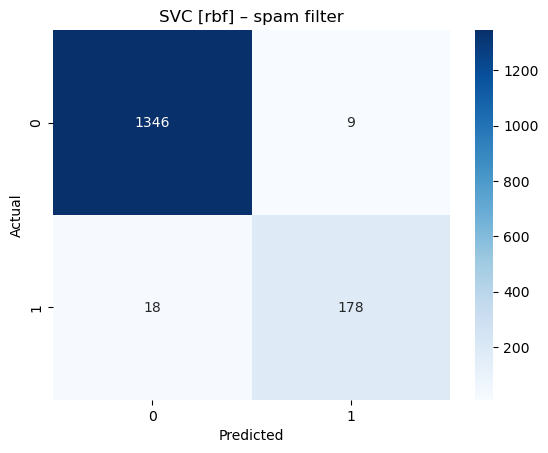

In [12]:
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

X = mail.drop(columns="spam"); y = mail["spam"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=5, stratify=y)

pipe = Pipeline([("scale", StandardScaler()), ("svc", SVC(kernel="rbf"))])
grid = GridSearchCV(pipe, {"svc__C": [0.1, 1, 10, 100], "svc__gamma": ["scale", 0.01, 0.1]}, cv=5, scoring="f1", n_jobs=-1)
grid.fit(X_train, y_train)

print("Best parameters :", grid.best_params_)
print(f"Best CV F1      : {grid.best_score_:.3f}\n")

y_pred = grid.predict(X_test)
print("Confusion matrix:\n", metrics.confusion_matrix(y_test, y_pred))
print(f"\nTest accuracy: {metrics.accuracy_score(y_test, y_pred):.3f}\n")
print(metrics.classification_report(y_test, y_pred, target_names=["Not spam", "Spam"]))

sns.heatmap(pd.crosstab(y_test, y_pred, rownames=["Actual"], colnames=["Predicted"]), annot=True, fmt="d", cmap="Blues")
plt.title("SVC [rbf] – spam filter"); plt.show()

In [13]:
# Classify two new messages
new_msgs = [
    "WINNER!! You have won a FREE prize. Call 09061701461 now to claim your reward! www.prize-claim.com",
    "Ok lol, I'll be there later. Sure, see you at the meeting tomorrow",
]
new_mail = pd.DataFrame([sms_features(t) for t in new_msgs])
new_mail["prediction"] = np.where(grid.predict(new_mail[X.columns]) == 1, "SPAM", "Not spam")
new_mail.insert(0, "message", [m[:45] + "..." for m in new_msgs])
new_mail

,message,freq_free,freq_win,freq_call,freq_lol,message_length,num_links,num_digits,capital_ratio,prediction
0,WINNER!! You have won a FREE prize. Call 0906...,5.88,23.53,17.65,0.00,98,1,11,0.182,SPAM
1,"Ok lol, I'll be there later. Sure, see you at...",0.00,0.00,0.00,30.77,66,0,0,0.060,Not spam
